# Objectif 

Date de création : 20/01/2025

Inversion des positions des OBS à partir des enregistrements des émissions actives. 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# import gc

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 
from real_data_analysis.fiberscope_groix.src.localisation.loc_utils import (
    f,
    jac,
    inverse_obs_loc,
)

# from misc import equivalent_celerity, calc_wls, draw_ellipse

In [4]:
# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

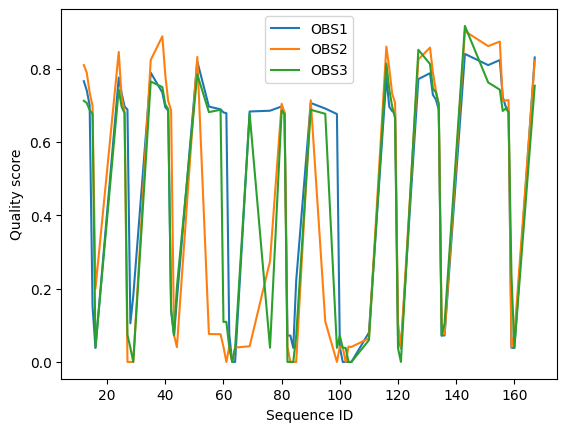

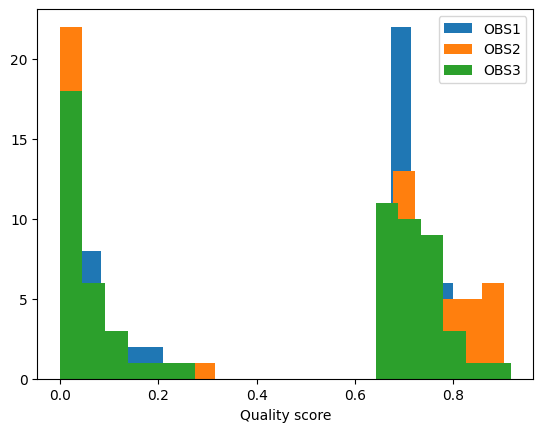

In [5]:
seq_ids = df_arr["Sequence_id"].unique()

# Plot f_score for each OBS

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[col_name].mean()        # Mean over constant array = val (kick trick to compute it)

    # Plot f_score 
    plt.plot(seq_ids, f_score, label=f"OBS{obs_id}")

plt.xlabel("Sequence ID")
plt.ylabel("Quality score")
plt.legend()

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[
        col_name
    ].mean()  # Mean over constant array = val (kick trick to compute it)

    # Plot f_score
    plt.hist(f_score, bins=20, label=f"OBS{obs_id}")

plt.xlabel("Quality score")
plt.legend()
# plt.ylabel("Quality score")

In [6]:
# Load synthetic data for comparison
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\synthetic_data\synthetic_data_20pos.nc"
ds_synthetic_arrivals = xr.open_dataset(fpath)
ds_synthetic_arrivals

<xarray.Dataset> Size: 2kB
Dimensions:         (id: 20)
Coordinates:
  * id              (id) int32 80B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
Data variables:
    x_no_noise      (id) float64 160B ...
    y_no_noise      (id) float64 160B ...
    z_no_noise      (id) float64 160B ...
    x               (id) float64 160B ...
    y               (id) float64 160B ...
    z               (id) float64 160B ...
    d_no_noise      (id) float64 160B ...
    d               (id) float64 160B ...
    t_arr_no_noise  (id) float64 160B ...
    t_arr           (id) float64 160B ...
Attributes:
    sigma_gps:   5
    sigma_time:  0.005

In [7]:
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


Estimated position : x = -1856.1656458512462, y = -1403.2073759133727, z = -1505.0950547104133
Residuals : index
0      2.727919e+06
1      2.726475e+06
2      2.724937e+06
3      2.711322e+06
4      2.738723e+06
           ...     
645   -3.698190e+06
646   -3.697239e+06
647   -3.693247e+06
648   -3.687720e+06
649   -3.686900e+06
Name: Measured propagation time OBS1, Length: 190, dtype: float64
Final cost : 1989845613201621.0
[[ 27428.09204075  -5886.11746118 -31234.29427659]
 [ -5886.11746118  28857.64761583 -12951.9842253 ]
 [-31234.29427659 -12951.9842253   55502.56160788]]
Estimated position : x = -667.2481701388019, y = 361.95829513040314, z = -2483.718638393472
Residuals : index
0      5.105203e+06
1      5.165106e+06
2      5.160497e+06
3      5.183053e+06
4      5.205793e+06
           ...     
645   -4.125069e+06
646   -4.127966e+06
647   -4.026906e+06
648   -4.094618e+06
649   -4.153577e+06
Name: Measured propagation time OBS2, Length: 270, dtype: float64
Final cost : 365609

findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


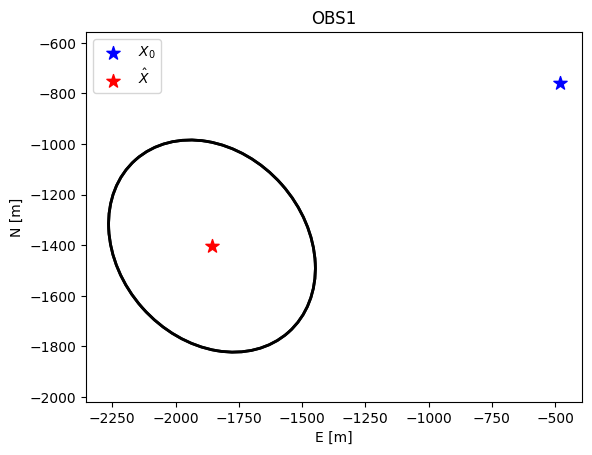

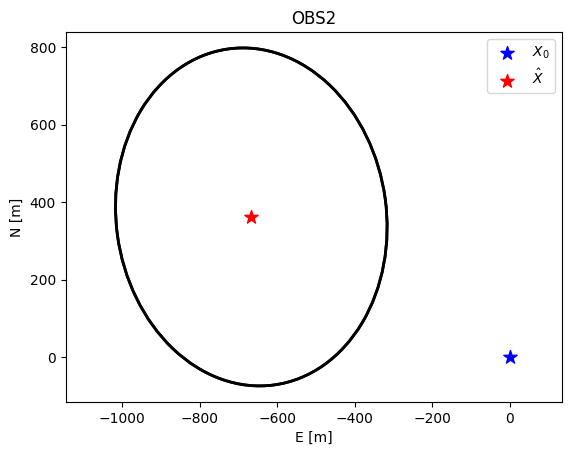

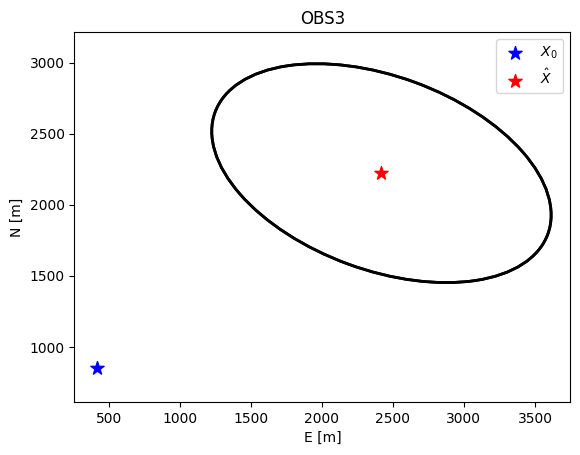

In [8]:
# Inverse position
min_f_score = 0.7

for obs_id in [1, 2, 3]:
    inverse_obs_loc(df_arr, ds_gps, obs_id, min_f_score, plot=True, verbose=True)